# GEEZ OCR

Ge'ez an ancient South Semitic language that originated in the Horn of Africa, specifically northern Ethiopia and southern Eritrea. It is the historical root or primary influence for modern Horn of African languages like Amharic, Tigrinya, and Tigré. t preserves centuries of invaluable historical chronicles, philosophical works, traditional medicine, and unique religious texts (including the Ge'ez Bible). It contain around 287 characters featuring 34 core base consonants, with each expanding into 7 vowel forms (orders) and irregular characters.

This project is going to use [Yaredoffice/geez-characters](https://huggingface.co/datasets/Yaredoffice/geez-characters) dataset to train an OCR model. The dataset was downloaded to the project in order to preprocess it and handle class label inference. 

## Import the necessary libraries and utility functions

In [2]:
%load_ext autoreload
%autoreload 2
import tensorflow as tf
import numpy as np
import sklearn as sk
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from utils import *
from models.ann_models import *
from models.cnn_models import *

## 1. Load and Explore the Dataset

### 1.1. Load the data

In [3]:
(X_train, y_train, train_paths), (X_test, y_test, test_paths)  = load_data("dataset")

Found 13776 files belonging to 287 classes.
Found 1435 files belonging to 287 classes.


### 1.2. Explore the data

In [3]:
print(f"X_train.shape  = {X_train.shape}")
print(f"Y_train.shape = {y_train.shape}")
print(f"X_test.shape  = {X_test.shape}")
print(f"Y_test.shape = {y_test.shape}")

print(f"X_train[0] is: \n{X_train[0]}\n")
print(f"X_train[-1] is: \n{X_train[-1]}\n")
print(f"Y_train[0] is: \n{y_train[0]}\n")
print(f"Y_train[-1] is: \n{y_train[-1]}\n")

X_train.shape  = (13776, 32, 32, 1)
Y_train.shape = (13776,)
X_test.shape  = (1435, 32, 32, 1)
Y_test.shape = (1435,)
X_train[0] is: 
[[[237.     ]
  [249.09375]
  [255.     ]
  ...
  [254.45312]
  [254.32812]
  [255.     ]]

 [[237.67188]
  [249.31421]
  [255.     ]
  ...
  [254.45312]
  [254.10767]
  [254.32812]]

 [[237.54688]
  [249.2732 ]
  [254.38403]
  ...
  [253.34155]
  [253.39111]
  [254.     ]]

 ...

 [[238.34375]
  [249.53467]
  [254.29907]
  ...
  [251.5647 ]
  [252.8584 ]
  [255.     ]]

 [[229.04688]
  [246.26367]
  [253.31958]
  ...
  [250.02368]
  [251.75342]
  [254.67188]]

 [[223.     ]
  [243.82812]
  [251.73438]
  ...
  [251.     ]
  [251.98438]
  [254.     ]]]

X_train[-1] is: 
[[[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 ...

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [

## 1.3. Show randomly selected images
Show randomly selected 20 images from both the training and test datasets with their actual labels to see what the images and characters look like.

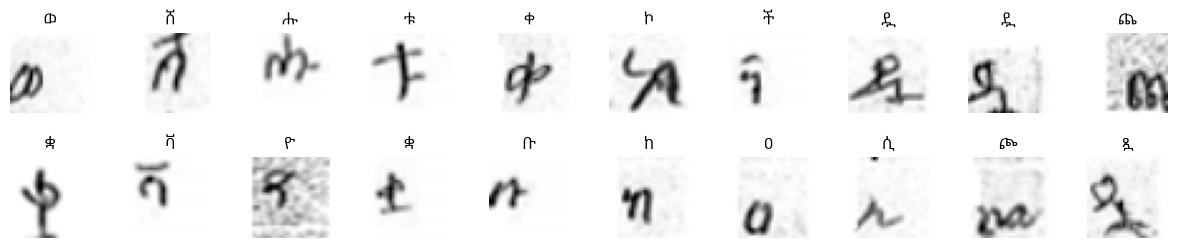

In [4]:
# From the training dataset
show_images(X_train, y_train, num_of_images=20)

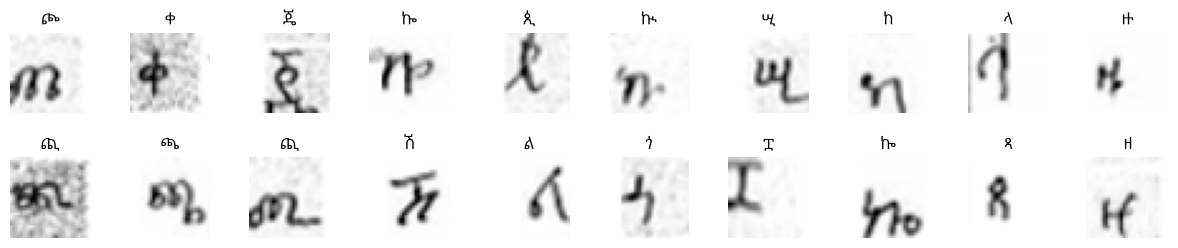

In [5]:
# From the test dataset
show_images(X_test, y_test, num_of_images=20)

## 2. Train and Fine-tune the Selected Models
Since the project is trying out different Artificial Neural Networks and Convolutional Neural Networks to identify Ge'ez characters, we are going to cross validate the models using `Stratified Folds` to test how well the models generalize to new unseen data. 

### 2.1. Overview of the Selected Model

In [4]:
regularized_deeper_cnn = build_regularized_deeper_cnn()
regularized_deeper_cnn.summary()

Model: "Regularized_Deeper_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ random_rotation (RandomRotation)     │ (None, 32, 32, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_zoom (RandomZoom)             │ (None, 32, 32, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_translation                   │ (None, 32, 32, 1)           │               0 │
│ (RandomTranslation)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 32, 32, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout2d (SpatialDropout2D) │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │              

 Total params: 517,663 (1.97 MB)

 Trainable params: 516,447 (1.97 MB)

 Non-trainable params: 1,216 (4.75 KB)

### 2.2 Further Train the Model using K-fold

I am going to use `Early Stopping` to stop training automatically as soon as validation loss stops improving.

In [5]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=8,
    restore_best_weights=True,
    min_delta=1e-3,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=1
)

In [30]:
print("=" * 50)
print("Deeper CNN Model")
print("=" * 50)
regularized_deeper_cnn_results = cross_validate_model(
    build_regularized_deeper_cnn,
    X_train,
    y_train,
    epochs=150,
    callback=[early_stopping, reduce_lr]
)

Deeper CNN Model

 ===================== Fold 1 =====================
Epoch 1/150
173/173 ━━━━━━━━━━━━━━━━━━━━ 34s 160ms/step - accuracy: 0.0032 - loss: 7.1026 - top5_accuracy: 0.0176 - val_accuracy: 0.0062 - val_loss: 6.9879 - val_top5_accuracy: 0.0232 - learning_rate: 2.5000e-04
Epoch 2/150
173/173 ━━━━━━━━━━━━━━━━━━━━ 26s 153ms/step - accuracy: 0.0053 - loss: 6.8986 - top5_accuracy: 0.0251 - val_accuracy: 0.0022 - val_loss: 6.8342 - val_top5_accuracy: 0.0200 - learning_rate: 2.5000e-04
Epoch 3/150
173/173 ━━━━━━━━━━━━━━━━━━━━ 27s 153ms/step - accuracy: 0.0100 - loss: 6.5985 - top5_accuracy: 0.0393 - val_accuracy: 0.0080 - val_loss: 6.6739 - val_top5_accuracy: 0.0327 - learning_rate: 2.5000e-04
Epoch 4/150
173/173 ━━━━━━━━━━━━━━━━━━━━ 26s 152ms/step - accuracy: 0.0133 - loss: 6.1513 - top5_accuracy: 0.0610 - val_accuracy: 0.0218 - val_loss: 5.9716 - val_top5_accuracy: 0.0762 - learning_rate: 2.5000e-04
Epoch 5/150
173/173 ━━━━━━━━━━━━━━━━━━━━ 26s 153ms/step - accuracy: 0.0220 - loss:

In [32]:
model_results = {}

# Mean of the results of the 5 fold trainings  of the model
summarized_results = summarize_results(regularized_deeper_cnn_results)
print(f"Mean Train Accuracy: {summarized_results["mean_train_accuracy"]}")
print(f"Mean Cross-Validation Accuracy: {summarized_results["mean_cv_accuracy"]}")
print(f"STD of Training Accuracy: {summarized_results["std_train_accuracy"]}")
print(f"STD of Cross-Validation Accuracy: {summarized_results["std_cv_accuracy"]}")
print(f"Mean Gap: {summarized_results["mean_gap"]}")
print(f"Mean Train Top 5 Accuracy: {summarized_results["mean_train_top5_accuracy"]}")
print(f"Mean Cross-Validation Top 5 Accuracy: {summarized_results["mean_cv_top5_accuracy"]}")

# Add the results to the ann results
model_results = summarized_results

Mean Train Accuracy: 0.8767603874206543
Mean Cross-Validation Accuracy: 0.8115557670593262
STD of Training Accuracy: 0.021848109799379647
STD of Cross-Validation Accuracy: 0.018889059022114095
Mean Gap: 0.06520462036132812
Mean Train Top 5 Accuracy: 0.9906903505325317
Mean Cross-Validation Top 5 Accuracy: 0.969294548034668


## 3. Train the Final Model

### 3.1. Train the Model
The number of epochs are determined from the continuos 5-fold trainings with the best perfromance.

In [8]:
X_dev, X_val, y_dev, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.10,
    stratify=y_train,
    random_state=42
)


model = build_regularized_deeper_cnn()

history = model.fit(
    X_dev,
    y_dev,
    validation_data=(X_val, y_val),
    epochs=100,
    callbacks=[
        reduce_lr, 
        early_stopping
    ],
    verbose=1
)

Epoch 1/100
388/388 ━━━━━━━━━━━━━━━━━━━━ 47s 95ms/step - accuracy: 0.0036 - loss: 7.0291 - top5_accuracy: 0.0203 - val_accuracy: 0.0109 - val_loss: 6.8451 - val_top5_accuracy: 0.0334 - learning_rate: 2.5000e-04
Epoch 2/100
388/388 ━━━━━━━━━━━━━━━━━━━━ 35s 90ms/step - accuracy: 0.0075 - loss: 6.5741 - top5_accuracy: 0.0390 - val_accuracy: 0.0189 - val_loss: 6.1501 - val_top5_accuracy: 0.0617 - learning_rate: 2.5000e-04
Epoch 3/100
388/388 ━━━━━━━━━━━━━━━━━━━━ 34s 88ms/step - accuracy: 0.0186 - loss: 5.9349 - top5_accuracy: 0.0791 - val_accuracy: 0.0094 - val_loss: 6.4424 - val_top5_accuracy: 0.0472 - learning_rate: 2.5000e-04
Epoch 4/100
388/388 ━━━━━━━━━━━━━━━━━━━━ 34s 88ms/step - accuracy: 0.0327 - loss: 5.4435 - top5_accuracy: 0.1300 - val_accuracy: 0.0806 - val_loss: 4.9450 - val_top5_accuracy: 0.2932 - learning_rate: 2.5000e-04
Epoch 5/100
388/388 ━━━━━━━━━━━━━━━━━━━━ 34s 88ms/step - accuracy: 0.0565 - loss: 4.9842 - top5_accuracy: 0.2142 - val_accuracy: 0.1096 - val_loss: 4.5389 -

**The model's evaluation on the development dataset which was splited from the training set.**

In [9]:
train_loss, train_acc, train_top5 = model.evaluate(
    X_dev,
    y_dev,
    verbose=1
)

val_loss, val_acc, val_top5 = model.evaluate(
    X_val,
    y_val,
    verbose=1
)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Train-Validation Gap: {train_acc - val_acc:.4f}")
print(f"Train Top-5: {train_top5:.4f}")
print(f"Validation Top-5: {val_top5:.4f}")

388/388 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9014 - loss: 0.7615 - top5_accuracy: 0.9948
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8527 - loss: 0.9874 - top5_accuracy: 0.9782
Train Accuracy: 0.9014
Validation Accuracy: 0.8527
Train-Validation Gap: 0.0488
Train Top-5: 0.9948
Validation Top-5: 0.9782


### 3.2. Save the Learned Model 

In [10]:
model.save("final_geez_cnn.keras")

### 3.3. Visualize the Training Process

#### 3.3.1. Visualize the training accuracy
The training accuracy is going to be lower than the actual evaluation training accuracy since I have used data agumentation during training.

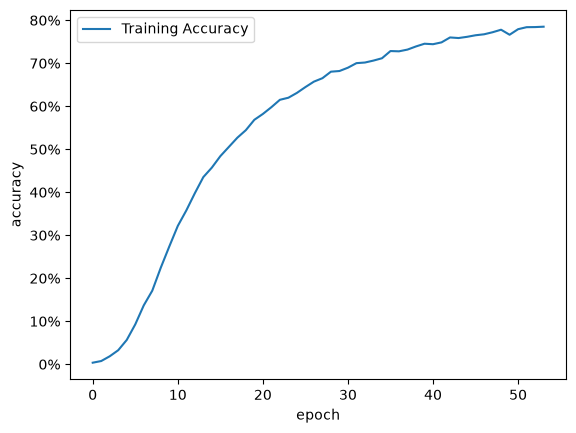

In [11]:
training_accuracy = history.history["accuracy"]

plt.plot(training_accuracy, label="Training Accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
plt.legend()
plt.show()

#### 3.3.2. Visualize the training loss

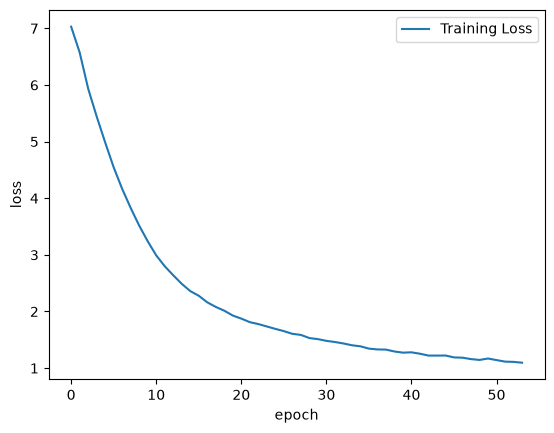

In [12]:
training_loss = history.history["loss"]

plt.plot(training_loss, label="Training Loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

#### 3.3.3. Visualize the top-5 training accuracy

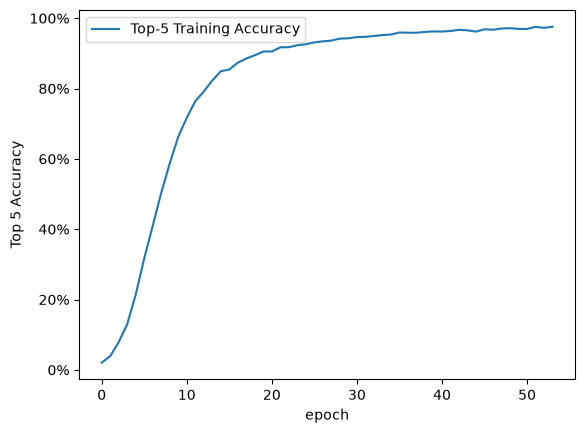

In [13]:
top5_training_accuracy = history.history["top5_accuracy"]

plt.plot(top5_training_accuracy, label="Top-5 Training Accuracy")
plt.xlabel("epoch")
plt.ylabel("Top 5 Accuracy")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
plt.legend()
plt.show()

## 3. Evaluate the Performance of the Model on the Training Set

### 3.1. Model's Performance on the Training Set

In [14]:
actual_training_loss, actual_training_accuracy, actual_top5_training_accuracy = model.evaluate(X_train, y_train)
print(f"The Model's Training Accuracy is: {actual_training_accuracy}")
print(f"The Model's Training Loss is: {actual_training_loss}")
print(f"The Model's Top 5 Training Accuracy: {actual_top5_training_accuracy}")

431/431 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.8966 - loss: 0.7841 - top5_accuracy: 0.9931
The Model's Training Accuracy is: 0.8965592384338379
The Model's Training Loss is: 0.7840856909751892
The Model's Top 5 Training Accuracy: 0.9931039214134216


### 3.2. Model's Prediction

In [15]:
# Get the models logit predictions
logit_predictions = model.predict(X_train)
# Check if the softmax_predictions are between 0 and 1 (probability distributions)
print(f"Logit Predictions")
print(f"The max number is: {np.max(logit_predictions)}")
print(f"The min number is: {np.min(logit_predictions)}\n")

# Change the logit outputs to probability distributions 
softmax_predictions = tf.nn.softmax(logit_predictions)
# Check if the softmax_predictions are between 0 and 1 (probability distributions)
print(f"Softmax Predictions")
print(f"The max number is: {np.max(softmax_predictions)}")
print(f"The min number is: {np.min(softmax_predictions)}\n")

# Get the predicted labels
predicted_labels = np.argmax(softmax_predictions, axis=1)
# Check f the predicted labels are between 0 and 286 digits
print(f"Label Predictions")
print(f"The max number is: {np.max(predicted_labels)}")
print(f"The min number is: {np.min(predicted_labels)}")

431/431 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step
Logit Predictions
The max number is: 6.824236869812012
The min number is: -87.81201171875

Softmax Predictions
The max number is: 0.9999136924743652
The min number is: 0.0

Label Predictions
The max number is: 286
The min number is: 0


### 3.3. Classification Report

In [16]:
report = classification_report(
    y_train,
    predicted_labels,
    labels=np.arange(287),
    target_names=GEEZ_CHARACTERS,
    digits=4,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

           ሀ     1.0000    0.9792    0.9895        48
           ለ     0.9184    0.9375    0.9278        48
           ሐ     0.9412    0.6667    0.7805        48
           መ     0.8182    0.9375    0.8738        48
           ሠ     0.9792    0.9792    0.9792        48
           ረ     0.9020    0.9583    0.9293        48
           ሰ     0.9302    0.8333    0.8791        48
           ሸ     0.8000    0.8333    0.8163        48
           ቀ     0.9583    0.9583    0.9583        48
           በ     0.9773    0.8958    0.9348        48
           ቨ     0.9730    0.7500    0.8471        48
           ተ     0.9592    0.9792    0.9691        48
           ቸ     0.9565    0.9167    0.9362        48
           ኀ     0.8491    0.9375    0.8911        48
           ነ     0.9545    0.8750    0.9130        48
           ኘ     0.9231    1.0000    0.9600        48
           አ     0.8800    0.9167    0.8980        48
           ከ     1.0000    

### 3.4.Visualize the Model's Predictions
Visualize randomly selected 30 images with their actual and predicted labels

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


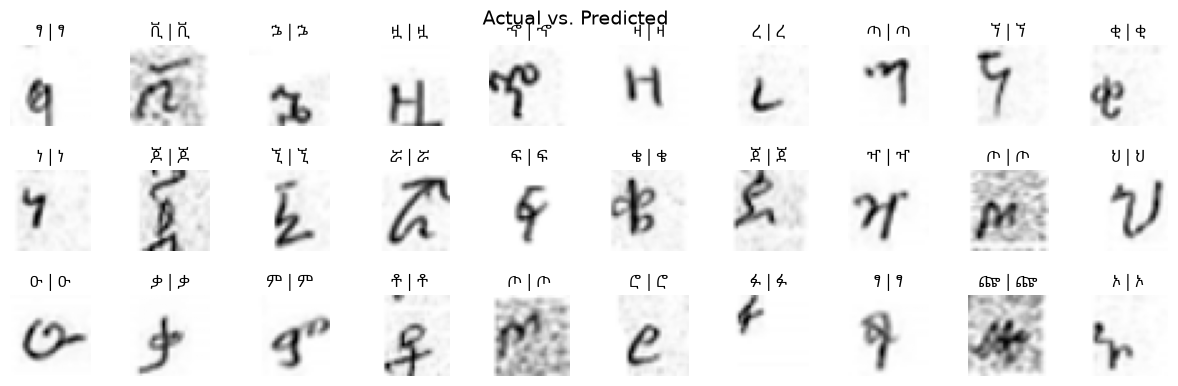

In [17]:
show_images_with_prediction(
    model,
    X_train,
    y_train,
    num_of_images = 30
)

### 3.5. Visualize the Model's Miscalssifications
Visualize the model's misclassifications in the training set

431/431 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step


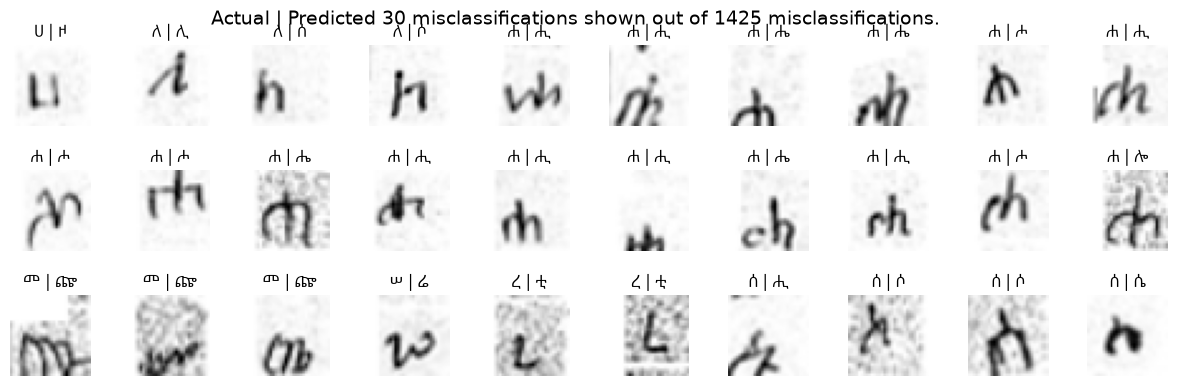

In [18]:
show_misclassifications(
    model,
    X_train,
    y_train,
    num_of_images=30
)

### 3.6. Evaluate Regular and Irregular Fidels (Characters) Separately
The Ge'ez script (Fidel) is an abugida, where each symbol represents a consonant-vowel combination. It consists of 34 base characters (for classical Ge'ez) which are modified into 7 vowel forms (orders). While the system is highly structured, it features both regular modification patterns and irregular exceptions caused by the shapes of certain base characters.

#### 3.6.1. Evaluation of regular fidels (characters)
For most characters, the vowels are added using a consistent set of rules or visual attachments

In [19]:
num_of_consonants = 34
num_of_vowels = 7
num_of_images_per_consonants = 48
first_irc_image = num_of_consonants * num_of_vowels * num_of_images_per_consonants


rc_training_loss, rc_training_accuracy, rc_top5_training_accuracy = model.evaluate(X_train[:first_irc_image], y_train[:first_irc_image])
print(f"The Model's Training Accuracy on Regular Fidels is: {rc_training_accuracy}")
print(f"The Model's Training Loss on Regular Fidels is: {rc_training_loss}")
print(f"The Model's Top 5 Training Accuracy on Regular Fidels is: {rc_top5_training_accuracy}")

357/357 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.8964 - loss: 0.7890 - top5_accuracy: 0.9929
The Model's Training Accuracy on Regular Fidels is: 0.8964460492134094
The Model's Training Loss on Regular Fidels is: 0.788966178894043
The Model's Top 5 Training Accuracy on Regular Fidels is: 0.9929096698760986


#### 3.6.2. Evaluation of irregular fidels (characters)
Characters that have rounded bottoms, a single central leg, or asymmetrical shapes cannot take standard attachments. They use completely unique modifications.

In [20]:
irc_training_loss, irc_training_accuracy, irc_top5_training_accuracy = model.evaluate(X_train[first_irc_image:], y_train[first_irc_image:])
print(f"The Model's Training Accuracy on Irregular Fidels is: {irc_training_accuracy}")
print(f"The Model's Training Loss on Irregular Fidels is: {irc_training_loss}")
print(f"The Model's Top 5 Training Accuracy on Irregular Fidels is: {irc_top5_training_accuracy}")

74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8971 - loss: 0.7604 - top5_accuracy: 0.9940
The Model's Training Accuracy on Irregular Fidels is: 0.8971088528633118
The Model's Training Loss on Irregular Fidels is: 0.7603822350502014
The Model's Top 5 Training Accuracy on Irregular Fidels is: 0.9940476417541504


## 4. Model Evaluation on The Test Dataset

### 4.1. Model Evaluation

In [21]:
test_loss, test_accuracy, top5_test_accuracy = model.evaluate(X_test, y_test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7679 - loss: 1.2571 - top5_accuracy: 0.9498


### 4.2. Classification Report 

In [22]:
yhat = model.predict(X_test)
yhat = tf.nn.softmax(yhat)
yhat = np.argmax(yhat, axis=1)

report = classification_report(
    y_test,
    yhat,
    labels=np.arange(287),
    target_names=GEEZ_CHARACTERS,
    digits=4,
    zero_division=0
)

print(report)

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
              precision    recall  f1-score   support

           ሀ     1.0000    0.6000    0.7500         5
           ለ     1.0000    0.6000    0.7500         5
           ሐ     0.6667    0.4000    0.5000         5
           መ     0.5714    0.8000    0.6667         5
           ሠ     1.0000    0.8000    0.8889         5
           ረ     0.5000    0.4000    0.4444         5
           ሰ     0.7143    1.0000    0.8333         5
           ሸ     0.8000    0.8000    0.8000         5
           ቀ     0.7143    1.0000    0.8333         5
           በ     0.7143    1.0000    0.8333         5
           ቨ     0.6667    0.8000    0.7273         5
           ተ     1.0000    0.8000    0.8889         5
           ቸ     1.0000    1.0000    1.0000         5
           ኀ     1.0000    0.8000    0.8889         5
           ነ     0.8333    1.0000    0.9091         5
           ኘ     0.8333    1.0000    0.9091         5
           አ     0.8333    1.0000    0.90

### 4.2. Visualize the Model's Predictions
Visualize randomly selected 30 images with their actual and predicted labels from the test set

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


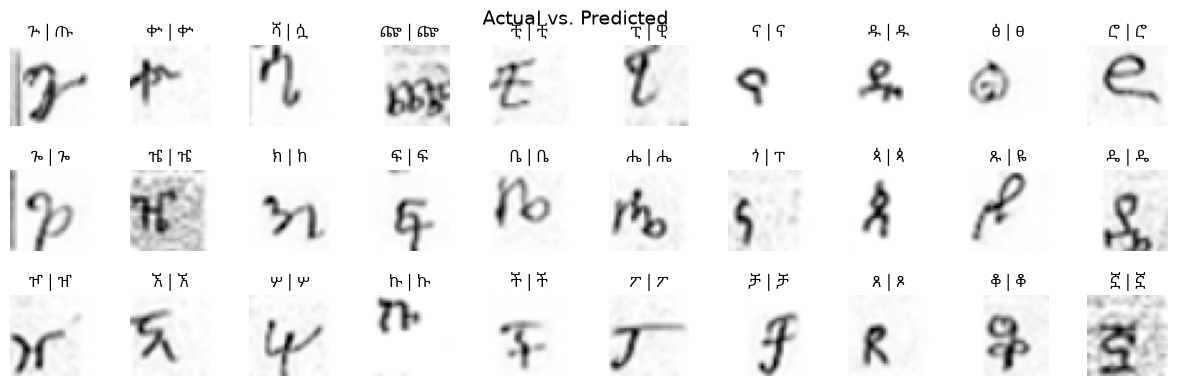

In [80]:
show_images_with_prediction(
    model,
    X_test,
    y_test,
    num_of_images = 30
)

### 4.3. Visualize the Mode's Misclassifications
Visualize the model's misclassifications on its preditions of the test set

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


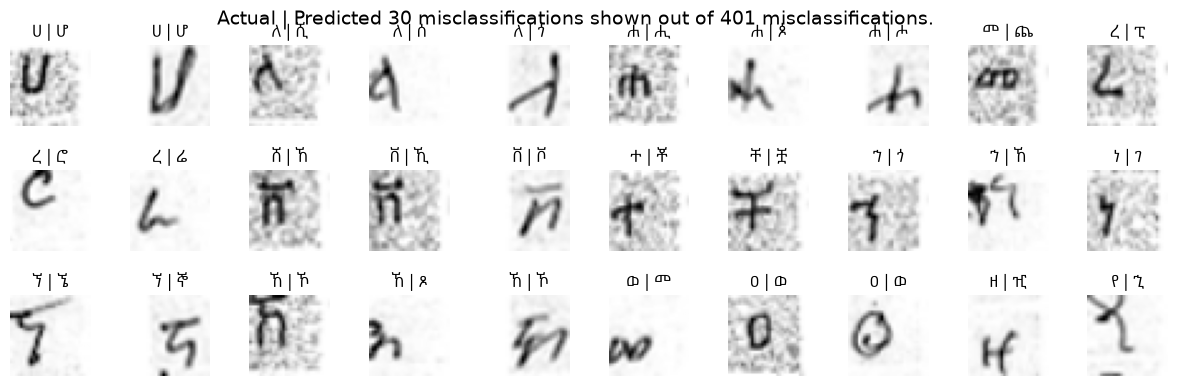

In [81]:
show_misclassifications(
    model,
    X_test,
    y_test,
    num_of_images=30
)